## Results Visualization & Document Length Analysis

**Objective:** Visualize the comparative performance of TF-IDF, LexRank, and SBERT across all evaluation metrics, and analyze the relationship between document length and summarization performance.

**Dataset:** Final combined dataframe (`final_df.pkl`) containing all summaries, ROUGE scores, coverage, and redundancy values for all three methods across 500 articles. (loaded via pickle - preserves list/dict column types that CSV serialization loses.)

**Steps:**
1. Load the final pickled dataframe
2. Grouped bar chart — ROUGE-1, ROUGE-2, ROUGE-L comparison across methods
3. Grouped bar chart — Coverage and Redundancy comparison across methods
4. Scatter plot — Coverage vs. Redundancy trade-off (one point per method)
5. Box plot — ROUGE-1 score distribution across 500 articles per method
6. Scatter plot — Word count vs. ROUGE-1 score, per method and combined
7. Regression plot — trend lines of ROUGE-1 vs. word count per method
8. Correlation heatmap — Pearson correlation between word count and each method's ROUGE-1 score, and between methods themselves

**Key Analytical Findings:**
- Scatter plot and Regression plot suggests, there's no evidence of performance degradation with increasing document length within the 800+ word range studied.
- No meaningful correlation between document length and ROUGE-1 performance within the 800+ word range (r ≈ 0.056–0.075 for all three methods)
- TF-IDF and LexRank are highly correlated (r = 0.869), consistent with both relying on lexical/frequency-based sentence selection
- SBERT shows more independent behavior (r ≈ 0.63–0.68 with the other two), reflecting its semantic rather than lexical sentence selection approach

These findings and all charts are discussed in detail in the accompanying [dissertation report](./report/Research-Dissertation.pdf).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
sample = pd.read_pickle('final_df.pkl')

In [4]:
sample.head(2)

,headline,title,text,word count,sentences,tfidf_summary,tfidf_score,rouge1_f,rouge2_f,rougeL_f,...,bert_score,bert_rouge1_f,bert_rouge2_f,bert_rougeL_f,bert_coverage,tfidf_coverage,lexrank_coverage,tfidf_redundancy,lexrank_redundancy,bert_redundancy
0,Meditate. Watch a movie. Spend time with frien...,How to Relax and De Stress3,"Meditating is a great way to relax your mind, ...",883,"[Meditating is a great way to relax your mind,...","When you watch a movie, try to clear your mind...","{'rouge1': (0.07471264367816093, 0.68421052631...",0.134715,0.031414,0.103627,...,"{'rouge1': (0.1791044776119403, 0.631578947368...",0.279070,0.095238,0.209302,0.631579,0.684211,0.684211,0.274856,0.278674,0.265933
1,Define your interest. Determine your medium. D...,How to Become a Beauty Guru,"The beauty industry is a huge one, and it’s ev...",1242,"[The beauty industry is a huge one, and it’s e...",In this vibrant industry where trends are cons...,"{'rouge1': (0.10344827586206896, 0.36206896551...",0.160920,0.030888,0.091954,...,"{'rouge1': (0.1794871794871795, 0.241379310344...",0.205882,0.044776,0.132353,0.241379,0.362069,0.362069,0.435117,0.347340,0.338566


In [60]:
sns.set_theme(style="whitegrid")

### **1. ROUGE Comparison (Bar Chart)**

In [6]:
results = pd.DataFrame({
    'Model': ['TF-IDF', 'TF-IDF', 'TF-IDF', 'LexRank', 'LexRank', 'LexRank', 'BERT', 'BERT', 'BERT'],
    'Metric': ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'ROUGE-1', 'ROUGE-2','ROUGE-L' ,'ROUGE-1' , 'ROUGE-2', 'ROUGE-L' ],
    'Score': [0.278, 0.066, 0.148, 0.313, 0.081, 0.170, 0.315, 0.072, 0.174]
})

results

,Model,Metric,Score
0,TF-IDF,ROUGE-1,0.278
1,TF-IDF,ROUGE-2,0.066
2,TF-IDF,ROUGE-L,0.148
3,LexRank,ROUGE-1,0.313
4,LexRank,ROUGE-2,0.081
5,LexRank,ROUGE-L,0.170
6,BERT,ROUGE-1,0.315
7,BERT,ROUGE-2,0.072
8,BERT,ROUGE-L,0.174


Text(0.5, 1.0, 'ROUGE Comparison ')

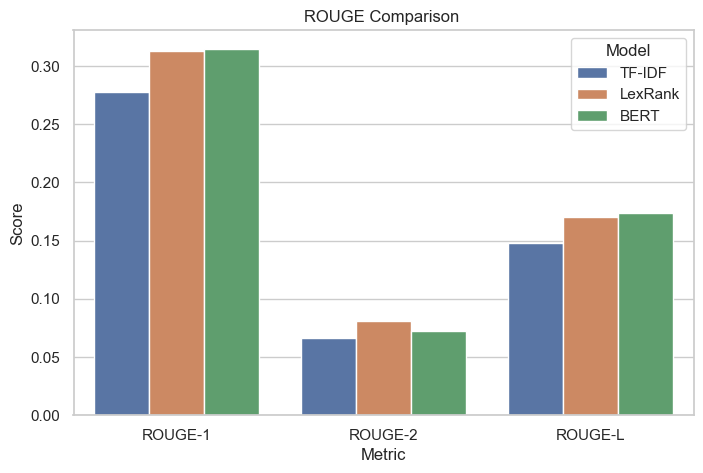

In [71]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results, x='Metric', y='Score', hue='Model')
plt.title('ROUGE Comparison ')

Text(0.5, 1.0, 'ROUGE Comaprison')

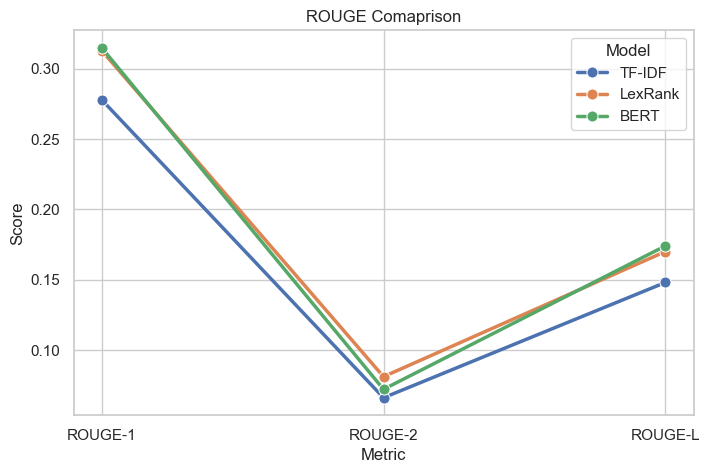

In [64]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=results, x='Metric', y='Score', hue='Model', marker='o', linewidth=2.5, markersize=8)
plt.title('ROUGE Comaprison')

### **2.Redundancy & Content Coverage Comparison (Bar Chart)**

* Coverage:  
bert_coverage       0.369990  
tfidf_coverage      0.532094  
lexrank_coverage    0.486582  

* Redundancy:  
tfidf_redundancy      0.399259  
lexrank_redundancy    0.442467  
bert_redundancy       0.324652  

In [8]:
results2 = pd.DataFrame({
    'Model':['TFIDF', 'TFIDF', 'LexRank', 'LexRank', 'BERT', 'BERT'],
    'Metric':['Coverage', 'Redundancy', 'Coverage', 'Redundancy', 'Coverage', 'Redundancy',],
    'Score':[0.532, 0.399, 0.487, 0.442, 0.370, 0.325]
})
results2

,Model,Metric,Score
0,TFIDF,Coverage,0.532
1,TFIDF,Redundancy,0.399
2,LexRank,Coverage,0.487
3,LexRank,Redundancy,0.442
4,BERT,Coverage,0.370
5,BERT,Redundancy,0.325


Text(0.5, 1.0, 'Redundancy & Content Coverage Comparison')

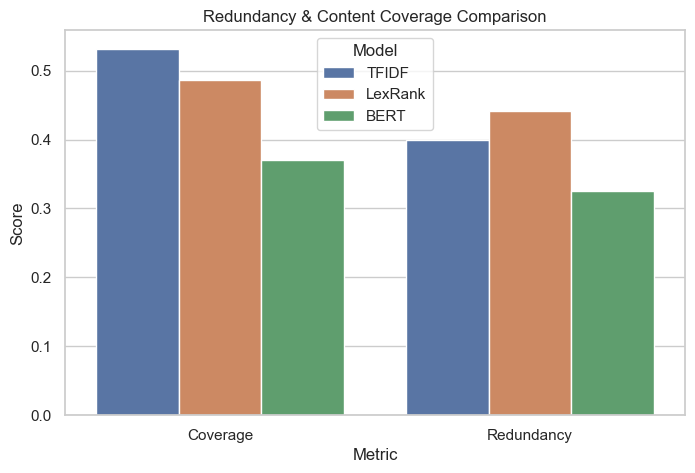

In [70]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results2, x='Metric', y='Score', hue='Model')
plt.title('Redundancy & Content Coverage Comparison')

### **3.Content Coverage vs Redundancy**

In [10]:
scatter_data = pd.DataFrame({
    'Model': ['TF-IDF', 'LexRank', 'BERT'],
    'Coverage': [0.532, 0.487, 0.370],
    'Redundancy': [0.399, 0.442, 0.325]
})
scatter_data

,Model,Coverage,Redundancy
0,TF-IDF,0.532,0.399
1,LexRank,0.487,0.442
2,BERT,0.370,0.325


Text(0.5, 1.0, 'Content Coverage vs Redundancy')

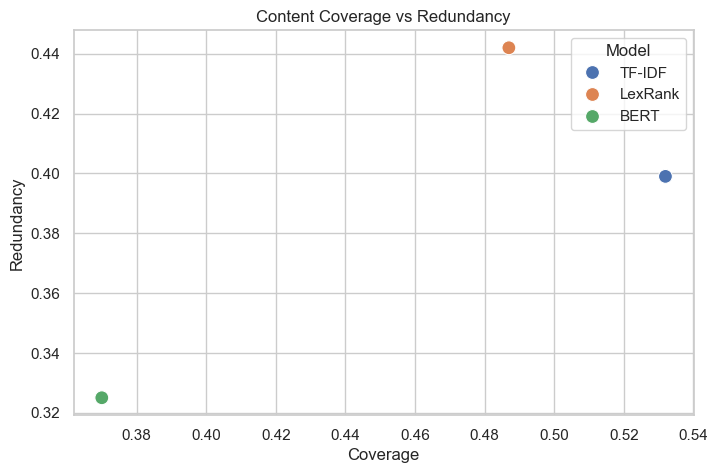

In [69]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=scatter_data, x='Coverage', y='Redundancy', hue='Model', s=100)
plt.title('Content Coverage vs Redundancy')

Observation:  
TF-IDF (top right) — high coverage but also high redundancy  
LexRank (top middle) — moderate coverage but highest redundancy — worst of both  
BERT (bottom left) — lowest redundancy but also lowest coverage

In [79]:
line_data = scatter_data.melt(id_vars='Model', var_name='Metric', value_name='score')
line_data

,Model,Metric,score
0,TF-IDF,Coverage,0.532
1,LexRank,Coverage,0.487
2,BERT,Coverage,0.370
3,TF-IDF,Redundancy,0.399
4,LexRank,Redundancy,0.442
5,BERT,Redundancy,0.325


Text(0.5, 1.0, 'Coverage vs Redundancy')

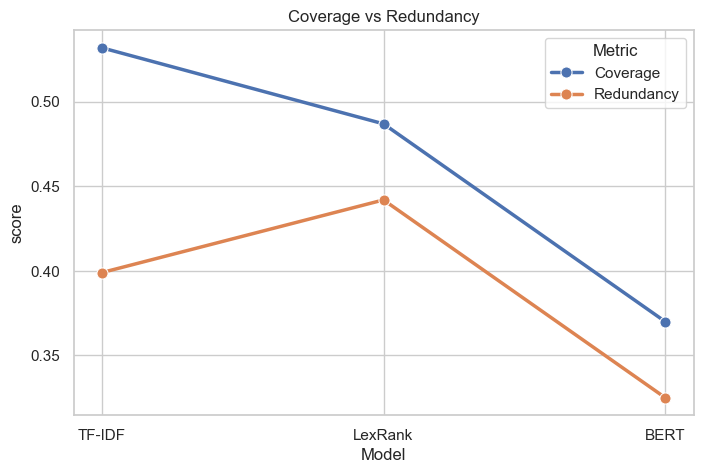

In [80]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=line_data, x='Model', y='score', hue='Metric', marker='o', linewidth=2.5, markersize=8)
plt.title('Coverage vs Redundancy')

### **4.Box Plot (ROUGE-1 Distribution)**

In [12]:
rouge1_data = sample[['rouge1_f', 'lexrank_rouge1_f', 'bert_rouge1_f']].melt()
#.melt() - unpivots the dataframe i.e. from many columns to many rows.
rouge1_data

,variable,value
0,rouge1_f,0.134715
1,rouge1_f,0.160920
2,rouge1_f,0.301587
3,rouge1_f,0.354369
4,rouge1_f,0.215278
...,...,...
1495,bert_rouge1_f,0.184615
1496,bert_rouge1_f,0.218543
1497,bert_rouge1_f,0.360825
1498,bert_rouge1_f,0.338462


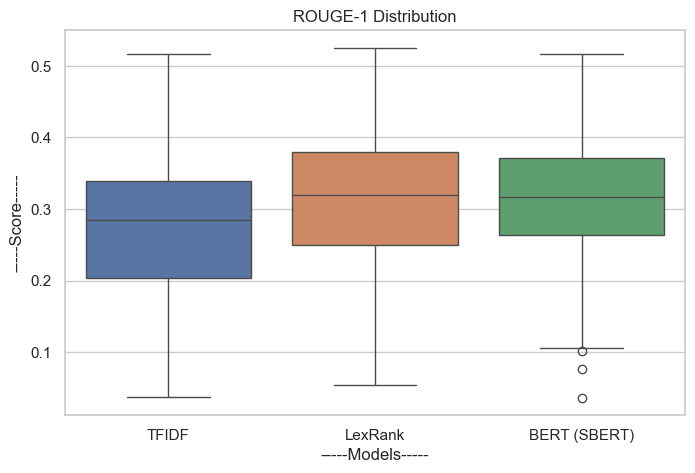

In [68]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=rouge1_data, x='variable', y='value', hue='variable')
plt.xticks(ticks=[0, 1, 2], labels=['TFIDF', 'LexRank', 'BERT (SBERT)'])
plt.xlabel('-----Models-----')
plt.ylabel('-----Score-----')
plt.title('ROUGE-1 Distribution')
plt.show()

Observation:  
TF-IDF has the lowest median and widest spread — most inconsistent  
LexRank and BERT have similar medians but BERT has a few outliers (those circles at the bottom)  
All three have similar upper ranges around 0.5

### **5.Scatter Plot (Word count vs ROUGE-1)**

In [14]:
sample.head(2)

,headline,title,text,word count,sentences,tfidf_summary,tfidf_score,rouge1_f,rouge2_f,rougeL_f,...,bert_score,bert_rouge1_f,bert_rouge2_f,bert_rougeL_f,bert_coverage,tfidf_coverage,lexrank_coverage,tfidf_redundancy,lexrank_redundancy,bert_redundancy
0,Meditate. Watch a movie. Spend time with frien...,How to Relax and De Stress3,"Meditating is a great way to relax your mind, ...",883,"[Meditating is a great way to relax your mind,...","When you watch a movie, try to clear your mind...","{'rouge1': (0.07471264367816093, 0.68421052631...",0.134715,0.031414,0.103627,...,"{'rouge1': (0.1791044776119403, 0.631578947368...",0.279070,0.095238,0.209302,0.631579,0.684211,0.684211,0.274856,0.278674,0.265933
1,Define your interest. Determine your medium. D...,How to Become a Beauty Guru,"The beauty industry is a huge one, and it’s ev...",1242,"[The beauty industry is a huge one, and it’s e...",In this vibrant industry where trends are cons...,"{'rouge1': (0.10344827586206896, 0.36206896551...",0.160920,0.030888,0.091954,...,"{'rouge1': (0.1794871794871795, 0.241379310344...",0.205882,0.044776,0.132353,0.241379,0.362069,0.362069,0.435117,0.347340,0.338566


Text(0.5, 1.0, 'TF-IDF')

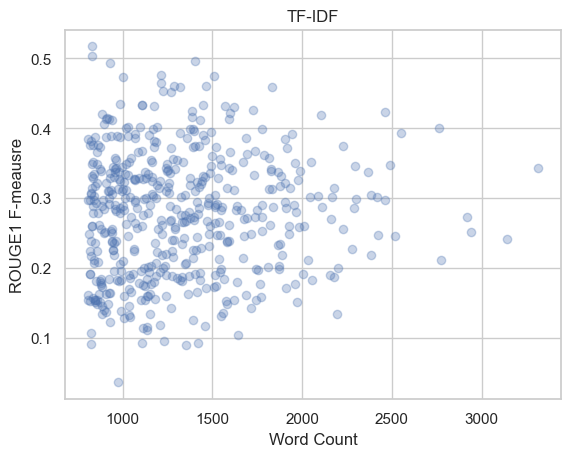

In [72]:
plt.scatter(sample['word count'], sample['rouge1_f'], alpha=0.3, label='TF-IDF')
plt.xlabel('Word Count')
plt.ylabel('ROUGE1 F-meausre')
plt.title('TF-IDF')

Text(0.5, 1.0, 'LexRank')

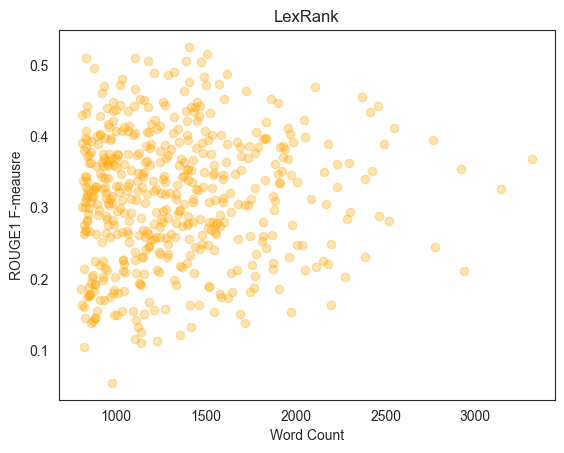

In [32]:
plt.scatter(sample['word count'], sample['lexrank_rouge1_f'], alpha=0.3, label='LexRank', color='orange')
plt.xlabel('Word Count')
plt.ylabel('ROUGE1 F-meausre')
plt.title('LexRank')

Text(0.5, 1.0, 'BERT')

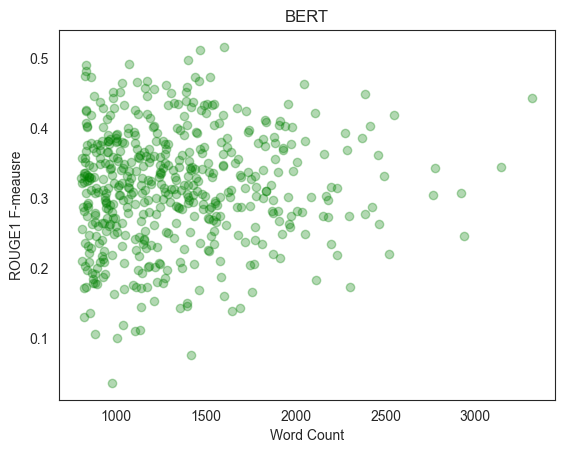

In [31]:
plt.scatter(sample['word count'], sample['bert_rouge1_f'], alpha=0.3, label='BERT',color = 'green')
plt.xlabel('Word Count')
plt.ylabel('ROUGE1 F-meausre')
plt.title('BERT')
           

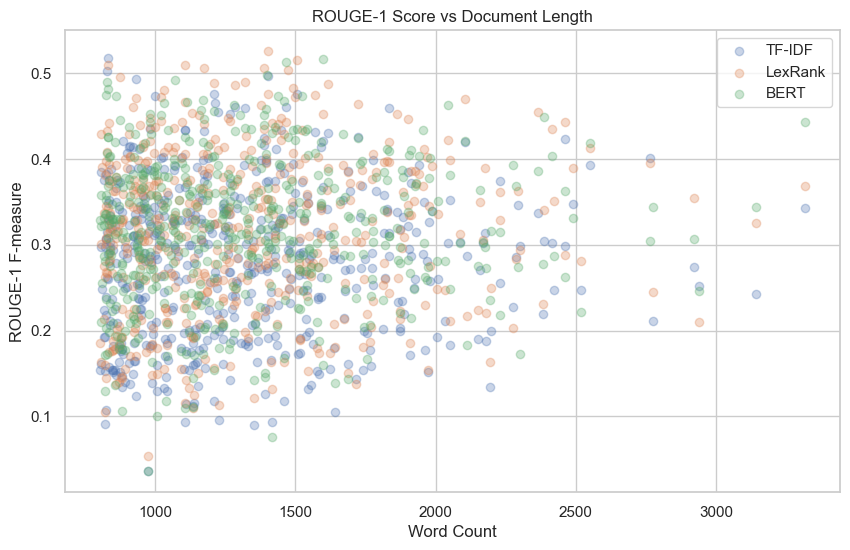

In [94]:
plt.figure(figsize=(10, 6)) 

plt.scatter(sample['word count'], sample['rouge1_f'], alpha=0.3, label='TF-IDF')
plt.scatter(sample['word count'], sample['lexrank_rouge1_f'], alpha=0.3, label='LexRank')
plt.scatter(sample['word count'], sample['bert_rouge1_f'], alpha=0.3, label='BERT')

plt.xlabel('Word Count')
plt.ylabel('ROUGE-1 F-measure')
plt.title('ROUGE-1 Score vs Document Length')
plt.legend()
plt.show()

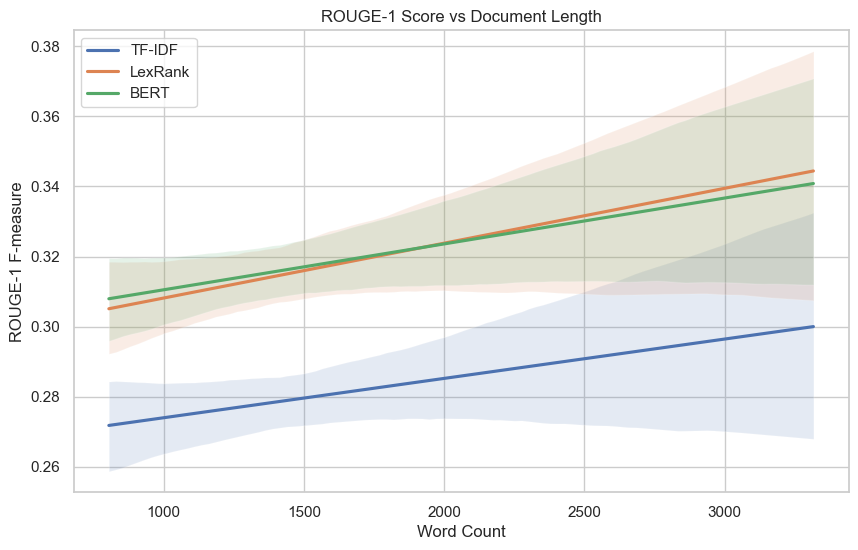

In [93]:
plt.figure(figsize=(10, 6))

for col, label in zip(['rouge1_f', 'lexrank_rouge1_f', 'bert_rouge1_f'],
                      ['TF-IDF', 'LexRank', 'BERT']):
    sns.regplot(data=sample, x='word count', y=col, scatter=False, label=label) #ci=None)

plt.xlabel('Word Count')
plt.ylabel('ROUGE-1 F-measure')
plt.title('ROUGE-1 Score vs Document Length')
plt.legend()
plt.show()

### **6.HeatMap - Correlation Analysis (Word count vs ROUGE-1)**

In [45]:
sample[['word count',
        'rouge1_f',
        'lexrank_rouge1_f',
        'bert_rouge1_f']].corr()

,word count,rouge1_f,lexrank_rouge1_f,bert_rouge1_f
word count,1.000000,0.055593,0.075067,0.069453
rouge1_f,0.055593,1.000000,0.869023,0.629835
lexrank_rouge1_f,0.075067,0.869023,1.000000,0.681508
bert_rouge1_f,0.069453,0.629835,0.681508,1.000000


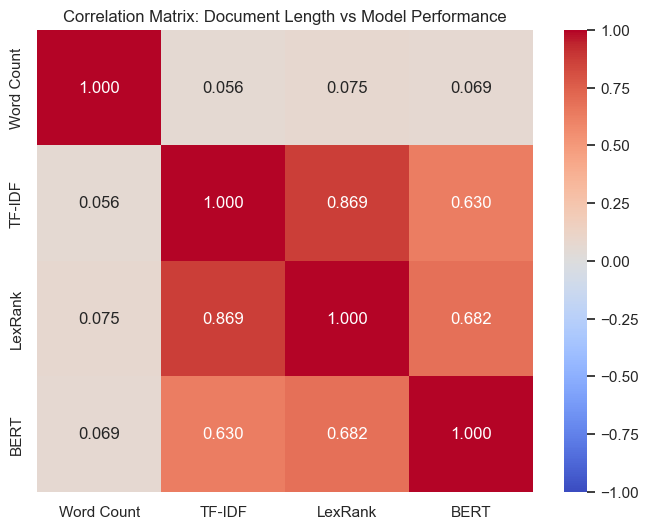

In [ ]:
plt.figure(figsize=(8, 6))
clean_labels = ['Word Count', 'TF-IDF', 'LexRank', 'BERT']

# annot=True puts the numbers in the boxes, cmap sets a nice scientific color profile
sns.heatmap(sample[['word count', 'rouge1_f', 'lexrank_rouge1_f', 'bert_rouge1_f']].corr(), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".3f",xticklabels=clean_labels,
            yticklabels=clean_labels)

plt.title('Correlation Matrix: Document Length vs Model Performance')
plt.show()